In [16]:
import warnings
import h3pandas
import pandas as pd
import xarray as xr
import earthaccess
import multiprocessing
import numpy as np
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from pyobis import occurrences

from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [2]:



auth = earthaccess.login(persist=True)

In [3]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL",
    temporal=("2025-01-01", "2025-12-31"),
    bounding_box=(-90.0, 40.0, -75.0, 47.0),
)

# Filter for the 1 degree dataset only, not the 4km high resolution.
fileset = earthaccess.open(results)
one_degree = [f for f in fileset if f.full_name.endswith("1deg.nc")]

len(one_degree)

/home/filipe/micromamba/envs/IOOS/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/home/filipe/micromamba/envs/IOOS/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/916 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/916 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/916 [00:00<?, ?it/s]

458

In [5]:
%%time


def fake_time(ds):
    time = ds.attrs["product_name"].split(".")[1].split("_")
    time = pd.to_datetime(time).mean()
    ds = ds.assign_coords(time=time)
    return ds["chlor_a"].expand_dims(time=1)


ds = xr.open_mfdataset(one_degree, preprocess=fake_time)
ds

CPU times: user 28.5 s, sys: 6.94 s, total: 35.4 s
Wall time: 13min 53s


<xarray.Dataset> Size: 12GB
Dimensions:  (time: 450, lat: 1800, lon: 3600)
Coordinates:
  * time     (time) datetime64[us] 4kB 2024-12-17T12:00:00 ... 2025-12-31
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Data variables:
    chlor_a  (time, lat, lon) float32 12GB dask.array<chunksize=(1, 512, 1024), meta=np.ndarray>

In [6]:
chlor_a = ds["chlor_a"].where(
    (ds["chlor_a"] < ds["chlor_a"].display_max)
    & (ds["chlor_a"] > ds["chlor_a"].display_min)
)

chlor_a = chlor_a.mean(dim="time").compute()

Query OBIS for phytoplankton (testing some generic groupings)

term | WoRMS | OBIS Map
-----|-------|---------
Diatoms (Bacillariophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=148899 | https://mapper.obis.org/?taxonid=148899
Dinoflagellates (Dinophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=19542 | https://mapper.obis.org/?taxonid=19542
Cyanobacteria (Blue-green algae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=146537 | https://mapper.obis.org/?taxonid=146537
Coccolithophyceae | https://www.marinespecies.org/aphia.php?p=taxdetails&id=592906 | https://mapper.obis.org/?taxonid=592906

## Generic search for occurrences for multiple aphia IDs.

Test and only return 100 records.

In [9]:
aphia_ids = ["148899", "19542", "146537", "592906"]

query = occurrences.search(taxonid=aphia_ids, size=100)
data = query.execute()

data

2026-07-02 16:12:09 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-07-02 16:12:09 - pyobis.obisutils - INFO - 100 to be fetched. Estimated time =0.0762377130985260 seconds
2026-07-02 16:12:09 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 100/100
2026-07-02 16:12:09 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-07-02 16:12:09 - pyobis.obisutils - INFO - Fetched 100 records.


,basisOfRecord,bibliographicCitation,brackish,catalogNumber,class,classid,collectionCode,coordinateUncertaintyInMeters,country,date_end,...,fieldNotes,preparations,verbatimLocality,associatedOccurrences,eventType,identificationVerificationStatus,identificationQualifier,individualCount,forma,formaid
0,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/35552-EF9455B8FFF22EFC18B3DCB74655...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.498349e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HumanObservation,Continuous Plankton Recorder (CPR) data from t...,True,23AC-43-172,Bacillariophyceae,148899.0,CPR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MaterialSample,"Focardi, Amaranta,Ostrowski, Martin,Goossen, K...",True,102.100.100/35991-3012DC434CD10C331A5B06F1EAFB...,Dinophyceae,19542.0,BioPlatforms Marine microbes in2016_v04,50.0,Australia,1.473984e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.676419e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.447891e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Occurrence,NaN,True,d2ec2d5e06a7683d488c60683531_ARVAM_60683531_AR...,Dinophyceae,19542.0,QUADRIGE - Coastal monitoring database and pro...,NaN,NaN,1.521072e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.558138e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,MATERIAL_SAMPLE,NaN,True,NaN,Cyanophyceae,146542.0,NaN,NaN,NaN,1.475712e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/34175-9BDF23CB027253367726EAD57B18...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.458691e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Query for gridded occurrence data for a the various aphia_ids

In [17]:
import geopandas as gpd

features = occurrences.grid(3, taxonid=aphia_ids).execute()

2026-07-02 16:15:04 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-07-02 16:15:04 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis


### Convert to geodataframe to visualize.

In [18]:
gdf = gpd.GeoDataFrame.from_features(features)

gdf

,geometry,n
0,"POLYGON ((150.46875 -35.15625, 151.875 -35.156...",1517518
1,"POLYGON ((153.28125 -28.125, 154.6875 -28.125,...",1090663
2,"POLYGON ((147.65625 -43.59375, 149.0625 -43.59...",980357
3,"POLYGON ((115.3125 -32.34375, 116.71875 -32.34...",911509
4,"POLYGON ((146.25 -19.6875, 147.65625 -19.6875,...",831334
...,...,...
8066,"POLYGON ((-150.46875 -70.3125, -149.0625 -70.3...",1
8067,"POLYGON ((-146.25 -87.1875, -144.84375 -87.187...",1
8068,"POLYGON ((-167.34375 -78.75, -165.9375 -78.75,...",1
8069,"POLYGON ((-178.59375 -73.125, -177.1875 -73.12...",1


## Plot the two side by side off the US East coast

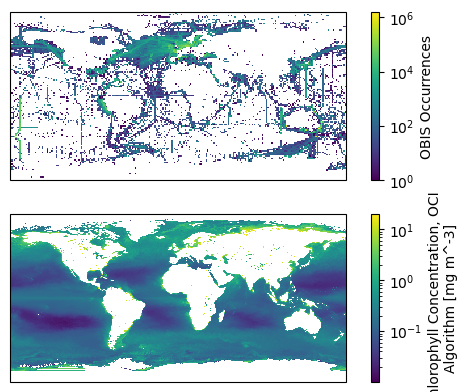

In [19]:
norm = colors.LogNorm()

projection = ccrs.PlateCarree()
fig, (ax0, ax1) = plt.subplots(nrows=2, subplot_kw={"projection": projection})

gdf.plot(
    column="n",
    norm=colors.LogNorm(),
    legend=True,
    legend_kwds={"label": "OBIS Occurrences"},
    ax=ax0,
)


cs = chlor_a.plot(norm=colors.LogNorm(), ax=ax1)

In [20]:
def average_chlor_a(geom):
    xmin, ymin, xmax, ymax = geom

    c = chlor_a.where(
        (xmin < chlor_a["lon"])
        & (chlor_a["lon"] < xmax)
        & (ymin < chlor_a["lat"])
        & (chlor_a["lat"] < ymax),
        drop=True,
    )
    return float(c.mean().to_numpy())

In [22]:
num_cores = multiprocessing.cpu_count()

bounds = gdf["geometry"].bounds.to_numpy()

chlor_avg = Parallel(n_jobs=num_cores)(
    delayed(average_chlor_a)(geom) for geom in bounds
) 

gdf["chlor_avg"] = chlor_avg

In [23]:
gdf["x"] = gdf["geometry"].centroid.x
gdf["y"] = gdf["geometry"].centroid.y

# The resolution goes from 0-15, using 2 b/c that is the closest to the OBIS squares.
resolution = 2

df = gdf[["x", "y", "n", "chlor_avg"]]

dfh3 = df.h3.geo_to_h3(
    resolution=resolution,
    lat_col="y",
    lng_col="x",
    set_index=True,
)


dfh3 = dfh3.drop(columns=["x", "y"]).groupby(dfh3.index.name).sum()
gdfh3 = dfh3.h3.h3_to_geo_boundary()

In [24]:
def fix_geom(geom):
    from shapely import Polygon

    lons, lats = map(list, geom.boundary.coords.xy)
    if max(abs(np.diff(lons))) > 180:
        xx = [x + 360 if x < 0 else x for x in lons]
        return Polygon(zip(xx, lats))
    else:
        return geom


gdfh3["geometry"] = gdfh3["geometry"].apply(fix_geom)
gdfh3["log_n"] = np.log(gdfh3["n"])

In [58]:
def norm(series):
    return (series - series.min()) / (series.max() - series.min())
    

gdfh3["chlor_norm"] = norm(gdfh3["chlor_avg"])
gdfh3["n_norm"] = norm(gdfh3["n"])

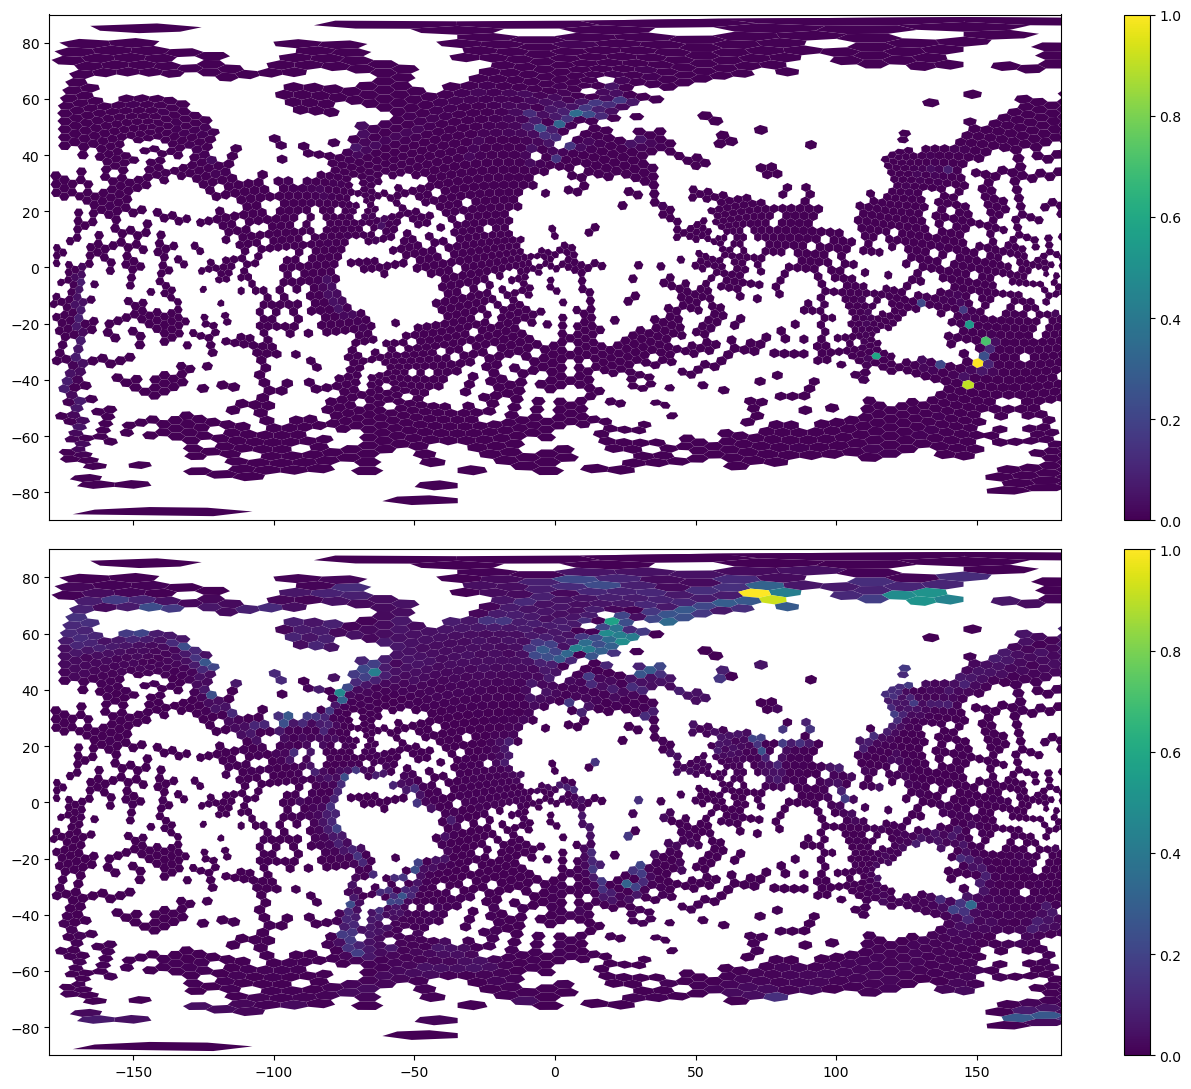

In [59]:
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(13, 11), sharex=True, sharey=True)

ax = gdfh3.plot(column="n_norm", ax=ax0, legend=True)
gdfh3.plot(column="chlor_norm", ax=ax1, legend=True)
ax0.axis([-180, 180, -90, 90])
fig.tight_layout()